In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

import os

In [2]:
os.makedirs("plots", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

In [3]:
before = pd.read_csv("BeforeAI.csv")
after = pd.read_csv("AfterAI.csv")

print("Before AI Shape:", before.shape)
print("After AI Shape:", after.shape)

Before AI Shape: (225745, 79)
After AI Shape: (1048575, 80)


In [8]:
before.columns

Index(['destination_port', 'flow_duration', 'total_fwd_packets',
       'total_backward_packets', 'total_length_of_fwd_packets',
       'total_length_of_bwd_packets', 'fwd_packet_length_max',
       'fwd_packet_length_min', 'fwd_packet_length_mean',
       'fwd_packet_length_std', 'bwd_packet_length_max',
       'bwd_packet_length_min', 'bwd_packet_length_mean',
       'bwd_packet_length_std', 'flow_bytes_s', 'flow_packets_s',
       'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min',
       'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max',
       'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std',
       'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags',
       'fwd_urg_flags', 'bwd_urg_flags', 'fwd_header_length',
       'bwd_header_length', 'fwd_packets_s', 'bwd_packets_s',
       'min_packet_length', 'max_packet_length', 'packet_length_mean',
       'packet_length_std', 'packet_length_variance', 'fin_flag_count',
       'syn_flag_co

In [9]:
after.columns

Index(['dst_port', 'protocol', 'timestamp', 'flow_duration', 'tot_fwd_pkts',
       'tot_bwd_pkts', 'totlen_fwd_pkts', 'totlen_bwd_pkts', 'fwd_pkt_len_max',
       'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_len_std',
       'bwd_pkt_len_max', 'bwd_pkt_len_min', 'bwd_pkt_len_mean',
       'bwd_pkt_len_std', 'flow_byts_s', 'flow_pkts_s', 'flow_iat_mean',
       'flow_iat_std', 'flow_iat_max', 'flow_iat_min', 'fwd_iat_tot',
       'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'fwd_iat_min',
       'bwd_iat_tot', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max',
       'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags',
       'bwd_urg_flags', 'fwd_header_len', 'bwd_header_len', 'fwd_pkts_s',
       'bwd_pkts_s', 'pkt_len_min', 'pkt_len_max', 'pkt_len_mean',
       'pkt_len_std', 'pkt_len_var', 'fin_flag_cnt', 'syn_flag_cnt',
       'rst_flag_cnt', 'psh_flag_cnt', 'ack_flag_cnt', 'urg_flag_cnt',
       'cwe_flag_count', 'ece_flag_cnt', 'down_up_ratio', 'pkt_size_avg',
      

In [10]:
column_mapping = {

    # Ports
    'dst_port': 'destination_port',

    # Packet counts
    'tot_fwd_pkts': 'total_fwd_packets',
    'tot_bwd_pkts': 'total_backward_packets',

    # Packet lengths
    'totlen_fwd_pkts': 'total_length_of_fwd_packets',
    'totlen_bwd_pkts': 'total_length_of_bwd_packets',

    # Forward packet stats
    'fwd_pkt_len_max': 'fwd_packet_length_max',
    'fwd_pkt_len_min': 'fwd_packet_length_min',
    'fwd_pkt_len_mean': 'fwd_packet_length_mean',
    'fwd_pkt_len_std': 'fwd_packet_length_std',

    # Backward packet stats
    'bwd_pkt_len_max': 'bwd_packet_length_max',
    'bwd_pkt_len_min': 'bwd_packet_length_min',
    'bwd_pkt_len_mean': 'bwd_packet_length_mean',
    'bwd_pkt_len_std': 'bwd_packet_length_std',

    # Flow traffic
    'flow_byts_s': 'flow_bytes_s',
    'flow_pkts_s': 'flow_packets_s',

    # Flow IAT
    'fwd_iat_tot': 'fwd_iat_total',
    'bwd_iat_tot': 'bwd_iat_total',

    # Header lengths
    'fwd_header_len': 'fwd_header_length',
    'bwd_header_len': 'bwd_header_length',

    # Packets/sec
    'fwd_pkts_s': 'fwd_packets_s',
    'bwd_pkts_s': 'bwd_packets_s',

    # Packet overall stats
    'pkt_len_min': 'min_packet_length',
    'pkt_len_max': 'max_packet_length',
    'pkt_len_mean': 'packet_length_mean',
    'pkt_len_std': 'packet_length_std',
    'pkt_len_var': 'packet_length_variance',

    # TCP flags
    'fin_flag_cnt': 'fin_flag_count',
    'syn_flag_cnt': 'syn_flag_count',
    'rst_flag_cnt': 'rst_flag_count',
    'psh_flag_cnt': 'psh_flag_count',
    'ack_flag_cnt': 'ack_flag_count',
    'urg_flag_cnt': 'urg_flag_count',
    'ece_flag_cnt': 'ece_flag_count',

    # Packet size avg
    'pkt_size_avg': 'average_packet_size',

    # Segment sizes
    'fwd_seg_size_avg': 'avg_fwd_segment_size',
    'bwd_seg_size_avg': 'avg_bwd_segment_size',

    # Window bytes
    'init_fwd_win_byts': 'init_win_bytes_forward',
    'init_bwd_win_byts': 'init_win_bytes_backward',

    # Active data packets
    'fwd_act_data_pkts': 'act_data_pkt_fwd',

    # Segment size
    'fwd_seg_size_min': 'min_seg_size_forward'
}

after.rename(columns=column_mapping, inplace=True)

print("Column harmonization completed.")

Column harmonization completed.


In [11]:
selected_features = [

    # Traffic persistence
    'flow_duration',

    # Packet counts
    'total_fwd_packets',
    'total_backward_packets',

    # Traffic intensity
    'flow_bytes_s',
    'flow_packets_s',

    # Packet behavior
    'fwd_packet_length_mean',
    'packet_length_mean',
    'packet_length_variance',

    # Protocol anomalies
    'syn_flag_count',
    'ack_flag_count',
    'psh_flag_count',
    'ece_flag_count',

    # Privacy-related behavior
    'average_packet_size',

    # Communication behavior
    'fwd_packets_s',
    'bwd_packets_s',

    # Labels
    'label'
]

print("Selected Features Ready")

Selected Features Ready


In [12]:
before_filtered = before[selected_features]

after_filtered = after[selected_features]

print(before_filtered.shape)
print(after_filtered.shape)

(225745, 16)
(1048575, 16)


In [13]:
before_sample = before_filtered.sample(
    n=50000,
    random_state=42
)

after_sample = after_filtered.sample(
    n=50000,
    random_state=42
)

print(before_sample.shape)
print(after_sample.shape)

(50000, 16)
(50000, 16)


In [14]:
before_sample['era'] = 0
after_sample['era'] = 1

In [15]:
combined = pd.concat(
    [before_sample, after_sample],
    ignore_index=True
)

print(combined.shape)

(100000, 17)


In [16]:
combined.replace([np.inf, -np.inf], np.nan, inplace=True)

combined.fillna(
    combined.median(numeric_only=True),
    inplace=True
)

print("Missing values handled.")

Missing values handled.


In [17]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

combined['label'] = encoder.fit_transform(
    combined['label'].astype(str)
)

print(combined['label'].value_counts())

label
1    36236
3    28503
0    21497
2    13764
Name: count, dtype: int64


In [18]:
combined['traffic_complexity_score'] = (

    0.20 * combined['flow_duration'] +

    0.20 * combined['flow_bytes_s'] +

    0.20 * combined['flow_packets_s'] +

    0.20 * combined['packet_length_variance'] +

    0.20 * combined['psh_flag_count']
)

combined['traffic_complexity_score'] = (

    combined['traffic_complexity_score']

    /

    combined['traffic_complexity_score'].max()
)

print("Traffic Complexity Score Created")

Traffic Complexity Score Created


In [19]:
features = [

    col for col in combined.columns

    if col != 'label'
]

X = combined[features]

y = combined['label']

print(X.shape)
print(y.shape)

(100000, 17)
(100000,)


**Feature Scaling**

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


**Train Test Split**

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (80000, 17)
Test Shape: (20000, 17)


**Federated Node Simulation**

In [22]:
node1_X = X_train[:len(X_train)//3]
node2_X = X_train[len(X_train)//3:2*len(X_train)//3]
node3_X = X_train[2*len(X_train)//3:]

node1_y = y_train[:len(y_train)//3]
node2_y = y_train[len(y_train)//3:2*len(y_train)//3]
node3_y = y_train[2*len(y_train)//3:]

print("Node 1:", node1_X.shape)
print("Node 2:", node2_X.shape)
print("Node 3:", node3_X.shape)

Node 1: (26666, 17)
Node 2: (26667, 17)
Node 3: (26667, 17)


**Differential Privacy**

In [23]:
def add_dp_noise(data, epsilon=1.0):

    noise = np.random.laplace(

        loc=0,

        scale=1/epsilon,

        size=data.shape
    )

    return data + noise

In [24]:
node1_X = add_dp_noise(node1_X)
node2_X = add_dp_noise(node2_X)
node3_X = add_dp_noise(node3_X)

print("Differential Privacy Applied")

Differential Privacy Applied


**Random Forest**

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42,

    n_jobs=-1
)

rf_model.fit(node1_X, node1_y)

rf_preds = rf_model.predict(X_test)

print("Random Forest Completed")

Random Forest Completed


**XGBoost**

In [27]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(

    n_estimators=100,

    max_depth=6,

    learning_rate=0.1,

    eval_metric='mlogloss',

    n_jobs=-1
)

xgb_model.fit(node2_X, node2_y)

xgb_preds = xgb_model.predict(X_test)

print("XGBoost Completed")

XGBoost Completed


**LSTM Data Preparation**

In [28]:
X_train_lstm = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test_lstm = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print(X_train_lstm.shape)

(80000, 17, 1)


In [29]:
lstm_model = Sequential()

lstm_model.add(

    LSTM(

        64,

        input_shape=(X_train.shape[1], 1)
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(32, activation='relu'))

lstm_model.add(

    Dense(

        len(np.unique(y)),

        activation='softmax'
    )
)

lstm_model.compile(

    loss='sparse_categorical_crossentropy',

    optimizer='adam',

    metrics=['accuracy']
)

print(lstm_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,108 (74.64 KB)

 Trainable params: 19,108 (74.64 KB)

 Non-trainable params: 0 (0.00 B)

None


In [30]:
history = lstm_model.fit(

    X_train_lstm,

    y_train,

    epochs=5,

    batch_size=64,

    validation_split=0.2,

    verbose=1
)

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8698 - loss: 0.3139 - val_accuracy: 0.9519 - val_loss: 0.1338
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9544 - loss: 0.1266 - val_accuracy: 0.9554 - val_loss: 0.1196
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9524 - loss: 0.1244 - val_accuracy: 0.9515 - val_loss: 0.1237
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9591 - loss: 0.1085 - val_accuracy: 0.9602 - val_loss: 0.0943
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9609 - loss: 0.1015 - val_accuracy: 0.9629 - val_loss: 0.0897


In [31]:
lstm_probs = lstm_model.predict(X_test_lstm)

lstm_preds = np.argmax(

    lstm_probs,

    axis=1
)

print("LSTM Predictions Completed")

625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
LSTM Predictions Completed


**Adaptive Hybrid Weighting**

In [32]:
complexity = X_test[:, -2]

final_preds = []

for i in range(len(X_test)):

    # Low complexity traffic
    if complexity[i] < 0.3:

        final_preds.append(rf_preds[i])

    # Medium complexity traffic
    elif complexity[i] < 0.6:

        final_preds.append(xgb_preds[i])

    # High complexity AI-era traffic
    else:

        final_preds.append(lstm_preds[i])

final_preds = np.array(final_preds)

print("Adaptive Hybrid Predictions Completed")

Adaptive Hybrid Predictions Completed


**Final Evaluation**

In [33]:
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score
)

accuracy = accuracy_score(
    y_test,
    final_preds
)

precision = precision_score(
    y_test,
    final_preds,
    average='weighted'
)

recall = recall_score(
    y_test,
    final_preds,
    average='weighted'
)

f1 = f1_score(
    y_test,
    final_preds,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9385
Precision: 0.9478884963261603
Recall   : 0.9385
F1 Score : 0.9367823545591922


In [34]:
models = {

    "Random Forest": rf_preds,

    "XGBoost": xgb_preds,

    "LSTM": lstm_preds,

    "Adaptive Hybrid": final_preds
}

for name, preds in models.items():

    acc = accuracy_score(y_test, preds)

    precision = precision_score(
        y_test,
        preds,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        preds,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        preds,
        average='weighted'
    )

    print(f"\n{name}")

    print("Accuracy :", round(acc,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))


Random Forest
Accuracy : 0.8793
Precision: 0.9067
Recall   : 0.8793
F1 Score : 0.8804

XGBoost
Accuracy : 0.8698
Precision: 0.9043
Recall   : 0.8698
F1 Score : 0.8715

LSTM
Accuracy : 0.9665
Precision: 0.9686
Recall   : 0.9665
F1 Score : 0.9662

Adaptive Hybrid
Accuracy : 0.9385
Precision: 0.9479
Recall   : 0.9385
F1 Score : 0.9368


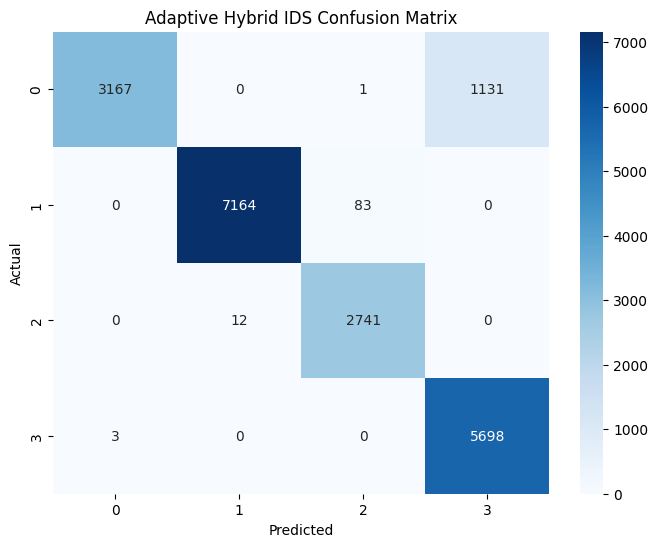

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Adaptive Hybrid IDS Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [36]:
results_df = pd.DataFrame({

    "Model": [

        "Random Forest",

        "XGBoost",

        "LSTM",

        "Adaptive Hybrid"
    ],

    "Accuracy": [

        accuracy_score(y_test, rf_preds),

        accuracy_score(y_test, xgb_preds),

        accuracy_score(y_test, lstm_preds),

        accuracy_score(y_test, final_preds)
    ],

    "Precision": [

        precision_score(
            y_test,
            rf_preds,
            average='weighted'
        ),

        precision_score(
            y_test,
            xgb_preds,
            average='weighted'
        ),

        precision_score(
            y_test,
            lstm_preds,
            average='weighted'
        ),

        precision_score(
            y_test,
            final_preds,
            average='weighted'
        )
    ],

    "Recall": [

        recall_score(
            y_test,
            rf_preds,
            average='weighted'
        ),

        recall_score(
            y_test,
            xgb_preds,
            average='weighted'
        ),

        recall_score(
            y_test,
            lstm_preds,
            average='weighted'
        ),

        recall_score(
            y_test,
            final_preds,
            average='weighted'
        )
    ],

    "F1 Score": [

        f1_score(
            y_test,
            rf_preds,
            average='weighted'
        ),

        f1_score(
            y_test,
            xgb_preds,
            average='weighted'
        ),

        f1_score(
            y_test,
            lstm_preds,
            average='weighted'
        ),

        f1_score(
            y_test,
            final_preds,
            average='weighted'
        )
    ]
})

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.8793,0.906739,0.8793,0.880376
1,XGBoost,0.8698,0.904259,0.8698,0.871477
2,LSTM,0.9665,0.968640,0.9665,0.966225
3,Adaptive Hybrid,0.9385,0.947888,0.9385,0.936782


In [37]:
results_df.to_csv(

    "results/model_comparison_results.csv",

    index=False
)

print("Results Saved Successfully")

Results Saved Successfully


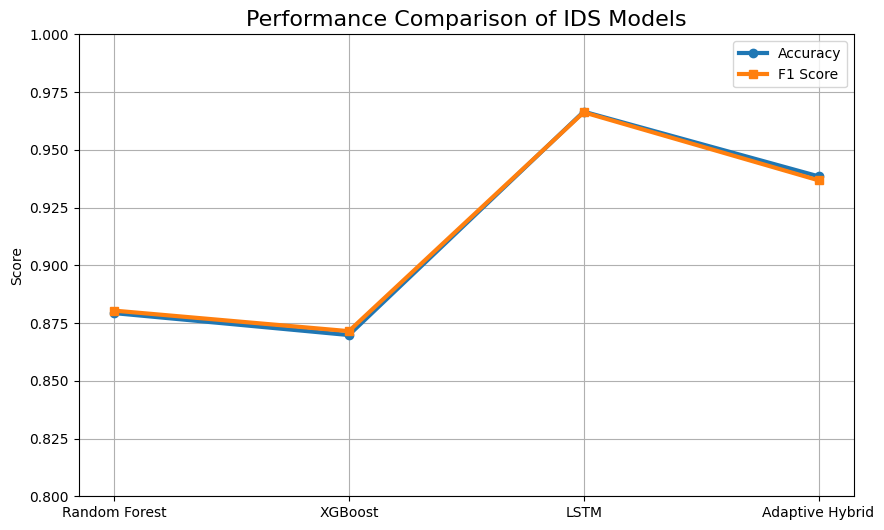

In [38]:
plt.figure(figsize=(10,6))

plt.plot(

    results_df["Model"],

    results_df["Accuracy"],

    marker='o',

    linewidth=3,

    label='Accuracy'
)

plt.plot(

    results_df["Model"],

    results_df["F1 Score"],

    marker='s',

    linewidth=3,

    label='F1 Score'
)

plt.title(

    "Performance Comparison of IDS Models",

    fontsize=16
)

plt.ylabel("Score")

plt.ylim(0.80, 1.0)

plt.grid(True)

plt.legend()

plt.show()

In [39]:
importance_df = pd.DataFrame({

    "Feature": features,

    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False
)

importance_df.head(10)

,Feature,Importance
15,era,0.185531
6,packet_length_mean,0.085422
12,average_packet_size,0.079614
5,fwd_packet_length_mean,0.071520
11,ece_flag_count,0.062022
9,ack_flag_count,0.061303
7,packet_length_variance,0.060098
10,psh_flag_count,0.046098
8,syn_flag_count,0.042791
0,flow_duration,0.041964


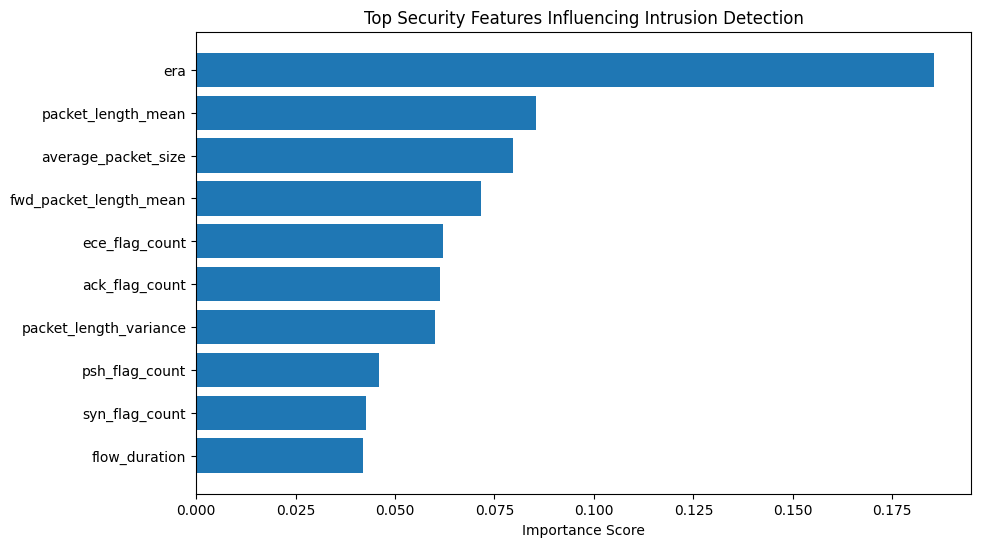

In [40]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(

    top_features["Feature"],

    top_features["Importance"]
)

plt.title(

    "Top Security Features Influencing Intrusion Detection"
)

plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

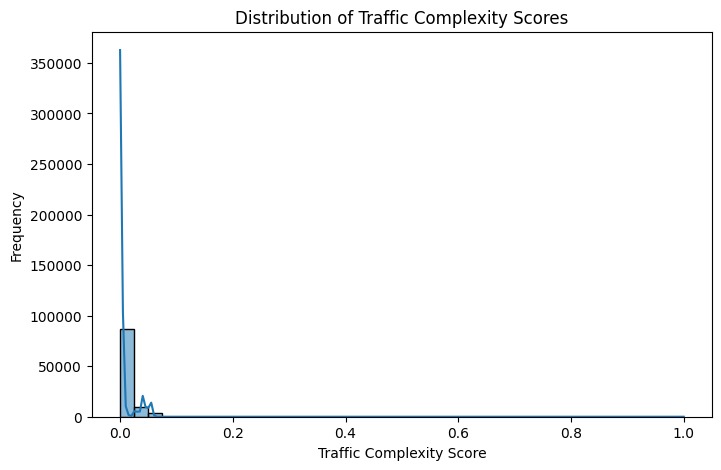

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(

    combined['traffic_complexity_score'],

    bins=40,

    kde=True
)

plt.title(

    "Distribution of Traffic Complexity Scores"
)

plt.xlabel("Traffic Complexity Score")

plt.ylabel("Frequency")

plt.show()

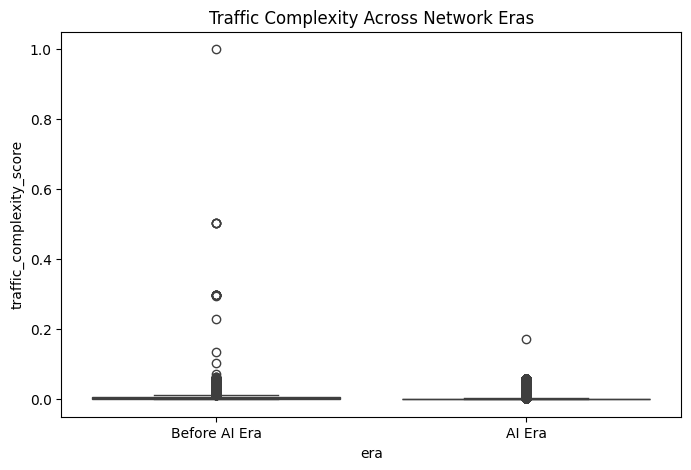

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(

    x='era',

    y='traffic_complexity_score',

    data=combined
)

plt.xticks(

    [0,1],

    ['Before AI Era', 'AI Era']
)

plt.title(

    "Traffic Complexity Across Network Eras"
)

plt.show()

In [43]:
combined['traffic_complexity_score'] = np.log1p(

    combined['traffic_complexity_score']
)

combined['traffic_complexity_score'] = (

    combined['traffic_complexity_score']

    /

    combined['traffic_complexity_score'].max()
)

In [44]:
from sklearn.metrics import classification_report

print(

    classification_report(

        y_test,

        final_preds
    )
)

              precision    recall  f1-score   support

           0       1.00      0.74      0.85      4299
           1       1.00      0.99      0.99      7247
           2       0.97      1.00      0.98      2753
           3       0.83      1.00      0.91      5701

    accuracy                           0.94     20000
   macro avg       0.95      0.93      0.93     20000
weighted avg       0.95      0.94      0.94     20000



**ROC Curve**

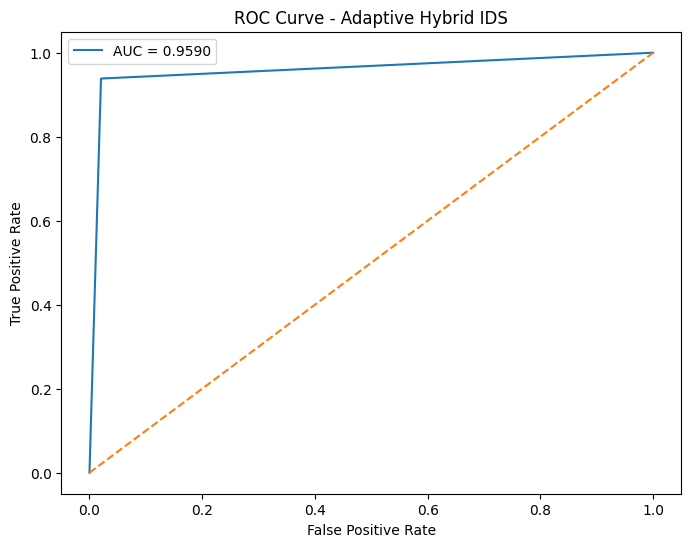

In [45]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(

    y_test,

    classes=np.unique(y_test)
)

final_preds_bin = label_binarize(

    final_preds,

    classes=np.unique(y_test)
)

fpr, tpr, _ = roc_curve(

    y_test_bin.ravel(),

    final_preds_bin.ravel()
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Adaptive Hybrid IDS")

plt.legend()

plt.show()

**Privacy Overhead Estimation**

In [46]:
original_size = X_train.nbytes / (1024 * 1024)

noisy_size = (
    node1_X.nbytes +
    node2_X.nbytes +
    node3_X.nbytes
) / (1024 * 1024)

privacy_overhead = noisy_size - original_size

print("Original Data Size (MB):", round(original_size,2))

print("Federated Noisy Data Size (MB):", round(noisy_size,2))

print("Privacy Preservation Overhead (MB):",

      round(privacy_overhead,2))

Original Data Size (MB): 10.38
Federated Noisy Data Size (MB): 10.38
Privacy Preservation Overhead (MB): 0.0
